In [2]:
import os
from google.cloud import bigquery
from google.cloud import storage
from google.cloud import bigquery_storage
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy import stats
import numpy as np
from scipy.stats import norm
from IPython.display import Image, display
#import libraries and put in key
key_path = "ultra-light-490500-g7-9d40a2cd1133.json"

Obtaining the data which in this case is from a public database of severe storms in the US during the year 2000

In [3]:
#obtain tornado data from BIG QUERY
sql = "SELECT *,CAST(event_end_time - event_begin_time AS STRING) AS duration FROM `bigquery-public-data.noaa_historic_severe_storms.storms_2000` WHERE event_type = 'tornado'"
client = bigquery.Client.from_service_account_json(key_path, project = 'ultra-light-490500-g7') #<<< your BigQuery project ID here!
query_job = client.query(sql)

In the Database there are multiple types of natural disasters such as floods and earthquakes since I need to look at the relation of these events I have decided to focus only on the tornados rows of the database

In [4]:
#Looking at dataframe 
df = query_job.to_dataframe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1666 entries, 0 to 1665
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   episode_id          1666 non-null   object        
 1   event_id            1666 non-null   object        
 2   state               1666 non-null   object        
 3   state_fips_code     1666 non-null   object        
 4   event_type          1666 non-null   object        
 5   cz_type             1666 non-null   object        
 6   cz_fips_code        1666 non-null   object        
 7   cz_name             1666 non-null   object        
 8   wfo                 1666 non-null   object        
 9   event_begin_time    1666 non-null   datetime64[us]
 10  event_timezone      1666 non-null   object        
 11  event_end_time      1666 non-null   datetime64[us]
 12  injuries_direct     1666 non-null   Int64         
 13  injuries_indirect   1666 non-null   Int64       

Now that I have obtained my data I will confirm my question of how certain factors effect the storm and removing any factors I think wont help with finding that

In [5]:
#remove columns with too little info or may not be relevant 
columns_to_remove = [
    'flood_cause',   #irrelevent
    'magnitude',     #irrelevent
    'magnitude_type',#irrelevent
    'flood_cause',  #irrelevent
    'tor_other_wfo',#nothing here 
    'episode_id',  #use event id
    'state',       #use coordinates
    'event_type',#everything already tornado
    'event_begin_time', #use duration
    'event_end_time',
    'reference_location',
    'deaths_indirect',   #not looking at injuries and deaths
    'injuries_direct',
    'injuries_indirect',
    'deaths_direct',
    'event_azimuth',   # Not relevant 
    'event_timezone',  #not relevant
    'state_fips_code',
    'cz_type',         # gonna use coordinates on tableu hopefully instead of codes for location so might as -
    'cz_fips_code',     # well remove them as it just inflates the data making it hard to read
    'cz_name',
    'damage_property',       #not calculating damages 
    'damage_crops',
    'source',
    'location_index',
    'wfo'
    ]
df_clean = df.drop(columns= columns_to_remove)

#note maybe just do a new dataframe

In [6]:
#dropping missing data as from the above info the only missing data still relevant are coordinates and you cant really 
#sum it up though if I really wanted to I could prob make estimations based on other location data provided but that would take alot
# of research
df_clean = df_clean.dropna() #

In [7]:
df_clean

,event_id,tor_f_scale,tor_length,tor_width,event_range,event_latitude,event_longitude,event_point,duration
9,5129729,F3,20.0,600.0,4.0,34.60000,-89.08333,POINT(-89.08333 34.6),0-0 0 0:10:0
10,5129729,F3,20.0,600.0,4.0,34.38333,-89.25000,POINT(-89.25 34.38333),0-0 0 0:10:0
11,5129620,F2,2.2,300.0,5.0,34.23333,-89.55000,POINT(-89.55 34.23333),0-0 0 0:10:0
12,5129620,F2,2.2,300.0,5.0,34.16667,-89.55000,POINT(-89.55 34.16667),0-0 0 0:10:0
13,5129728,F2,21.0,150.0,3.0,34.38333,-89.26667,POINT(-89.26667 34.38333),0-0 0 0:20:0
...,...,...,...,...,...,...,...,...,...
1656,5178380,F2,12.0,440.0,4.0,32.40000,-88.66667,POINT(-88.66667 32.4),0-0 0 0:15:0
1657,5178403,F0,0.1,0.1,2.0,34.10000,-82.63333,POINT(-82.63333 34.1),0-0 0 0:0:0
1658,5177930,F0,0.5,80.0,4.0,29.06667,-80.93333,POINT(-80.93333 29.06667),0-0 0 0:0:0
1659,5177931,F0,2.5,40.0,5.0,39.01667,-91.95000,POINT(-91.95 39.01667),0-0 0 0:2:0


In [8]:
#checking for info after adjusting the table
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1344 entries, 9 to 1660
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_id         1344 non-null   object 
 1   tor_f_scale      1344 non-null   object 
 2   tor_length       1344 non-null   object 
 3   tor_width        1344 non-null   object 
 4   event_range      1344 non-null   float64
 5   event_latitude   1344 non-null   float64
 6   event_longitude  1344 non-null   float64
 7   event_point      1344 non-null   object 
 8   duration         1344 non-null   object 
dtypes: float64(3), object(6)
memory usage: 105.0+ KB


In [9]:
#turning duration into a interger 
def parse_duration_to_minutes(x):
    try:
        part1, part2, time_part = x.split()
        
        days, hours1 = map(int, part1.split('-'))
        hours2 = int(part2)
        h, m, s = map(int, time_part.split(':'))
        
        total_minutes = (
            days * 1440 +        # days → minutes
            hours1 * 60 +
            hours2 * 60 +
            h * 60 +
            m                   # ignore seconds
        )
        
        return total_minutes
    except:
        return None

df_clean['duration_minutes'] = df_clean['duration'].apply(parse_duration_to_minutes)

In [10]:
df_clean

,event_id,tor_f_scale,tor_length,tor_width,event_range,event_latitude,event_longitude,event_point,duration,duration_minutes
9,5129729,F3,20.0,600.0,4.0,34.60000,-89.08333,POINT(-89.08333 34.6),0-0 0 0:10:0,10
10,5129729,F3,20.0,600.0,4.0,34.38333,-89.25000,POINT(-89.25 34.38333),0-0 0 0:10:0,10
11,5129620,F2,2.2,300.0,5.0,34.23333,-89.55000,POINT(-89.55 34.23333),0-0 0 0:10:0,10
12,5129620,F2,2.2,300.0,5.0,34.16667,-89.55000,POINT(-89.55 34.16667),0-0 0 0:10:0,10
13,5129728,F2,21.0,150.0,3.0,34.38333,-89.26667,POINT(-89.26667 34.38333),0-0 0 0:20:0,20
...,...,...,...,...,...,...,...,...,...,...
1656,5178380,F2,12.0,440.0,4.0,32.40000,-88.66667,POINT(-88.66667 32.4),0-0 0 0:15:0,15
1657,5178403,F0,0.1,0.1,2.0,34.10000,-82.63333,POINT(-82.63333 34.1),0-0 0 0:0:0,0
1658,5177930,F0,0.5,80.0,4.0,29.06667,-80.93333,POINT(-80.93333 29.06667),0-0 0 0:0:0,0
1659,5177931,F0,2.5,40.0,5.0,39.01667,-91.95000,POINT(-91.95 39.01667),0-0 0 0:2:0,2


In [11]:
#turning neccesary columns into numeric 
cols_to_try = [
    "tor_length", "tor_width","duration_minutes"
]

for col in cols_to_try:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
#

In [12]:
#need to make scale numeric for correlation
df_clean['tor_f_scale_num'] = (
    df_clean['tor_f_scale']
    .str.extract(r'(\d+)')   # pull out the number
    .astype(float)
)

In [13]:
df_clean.info() #checking if changing to numeric works 

<class 'pandas.core.frame.DataFrame'>
Index: 1344 entries, 9 to 1660
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event_id          1344 non-null   object 
 1   tor_f_scale       1344 non-null   object 
 2   tor_length        1344 non-null   float64
 3   tor_width         1344 non-null   float64
 4   event_range       1344 non-null   float64
 5   event_latitude    1344 non-null   float64
 6   event_longitude   1344 non-null   float64
 7   event_point       1344 non-null   object 
 8   duration          1344 non-null   object 
 9   duration_minutes  1344 non-null   int64  
 10  tor_f_scale_num   1344 non-null   float64
dtypes: float64(6), int64(1), object(4)
memory usage: 126.0+ KB


**Showing the correlation between each variable**

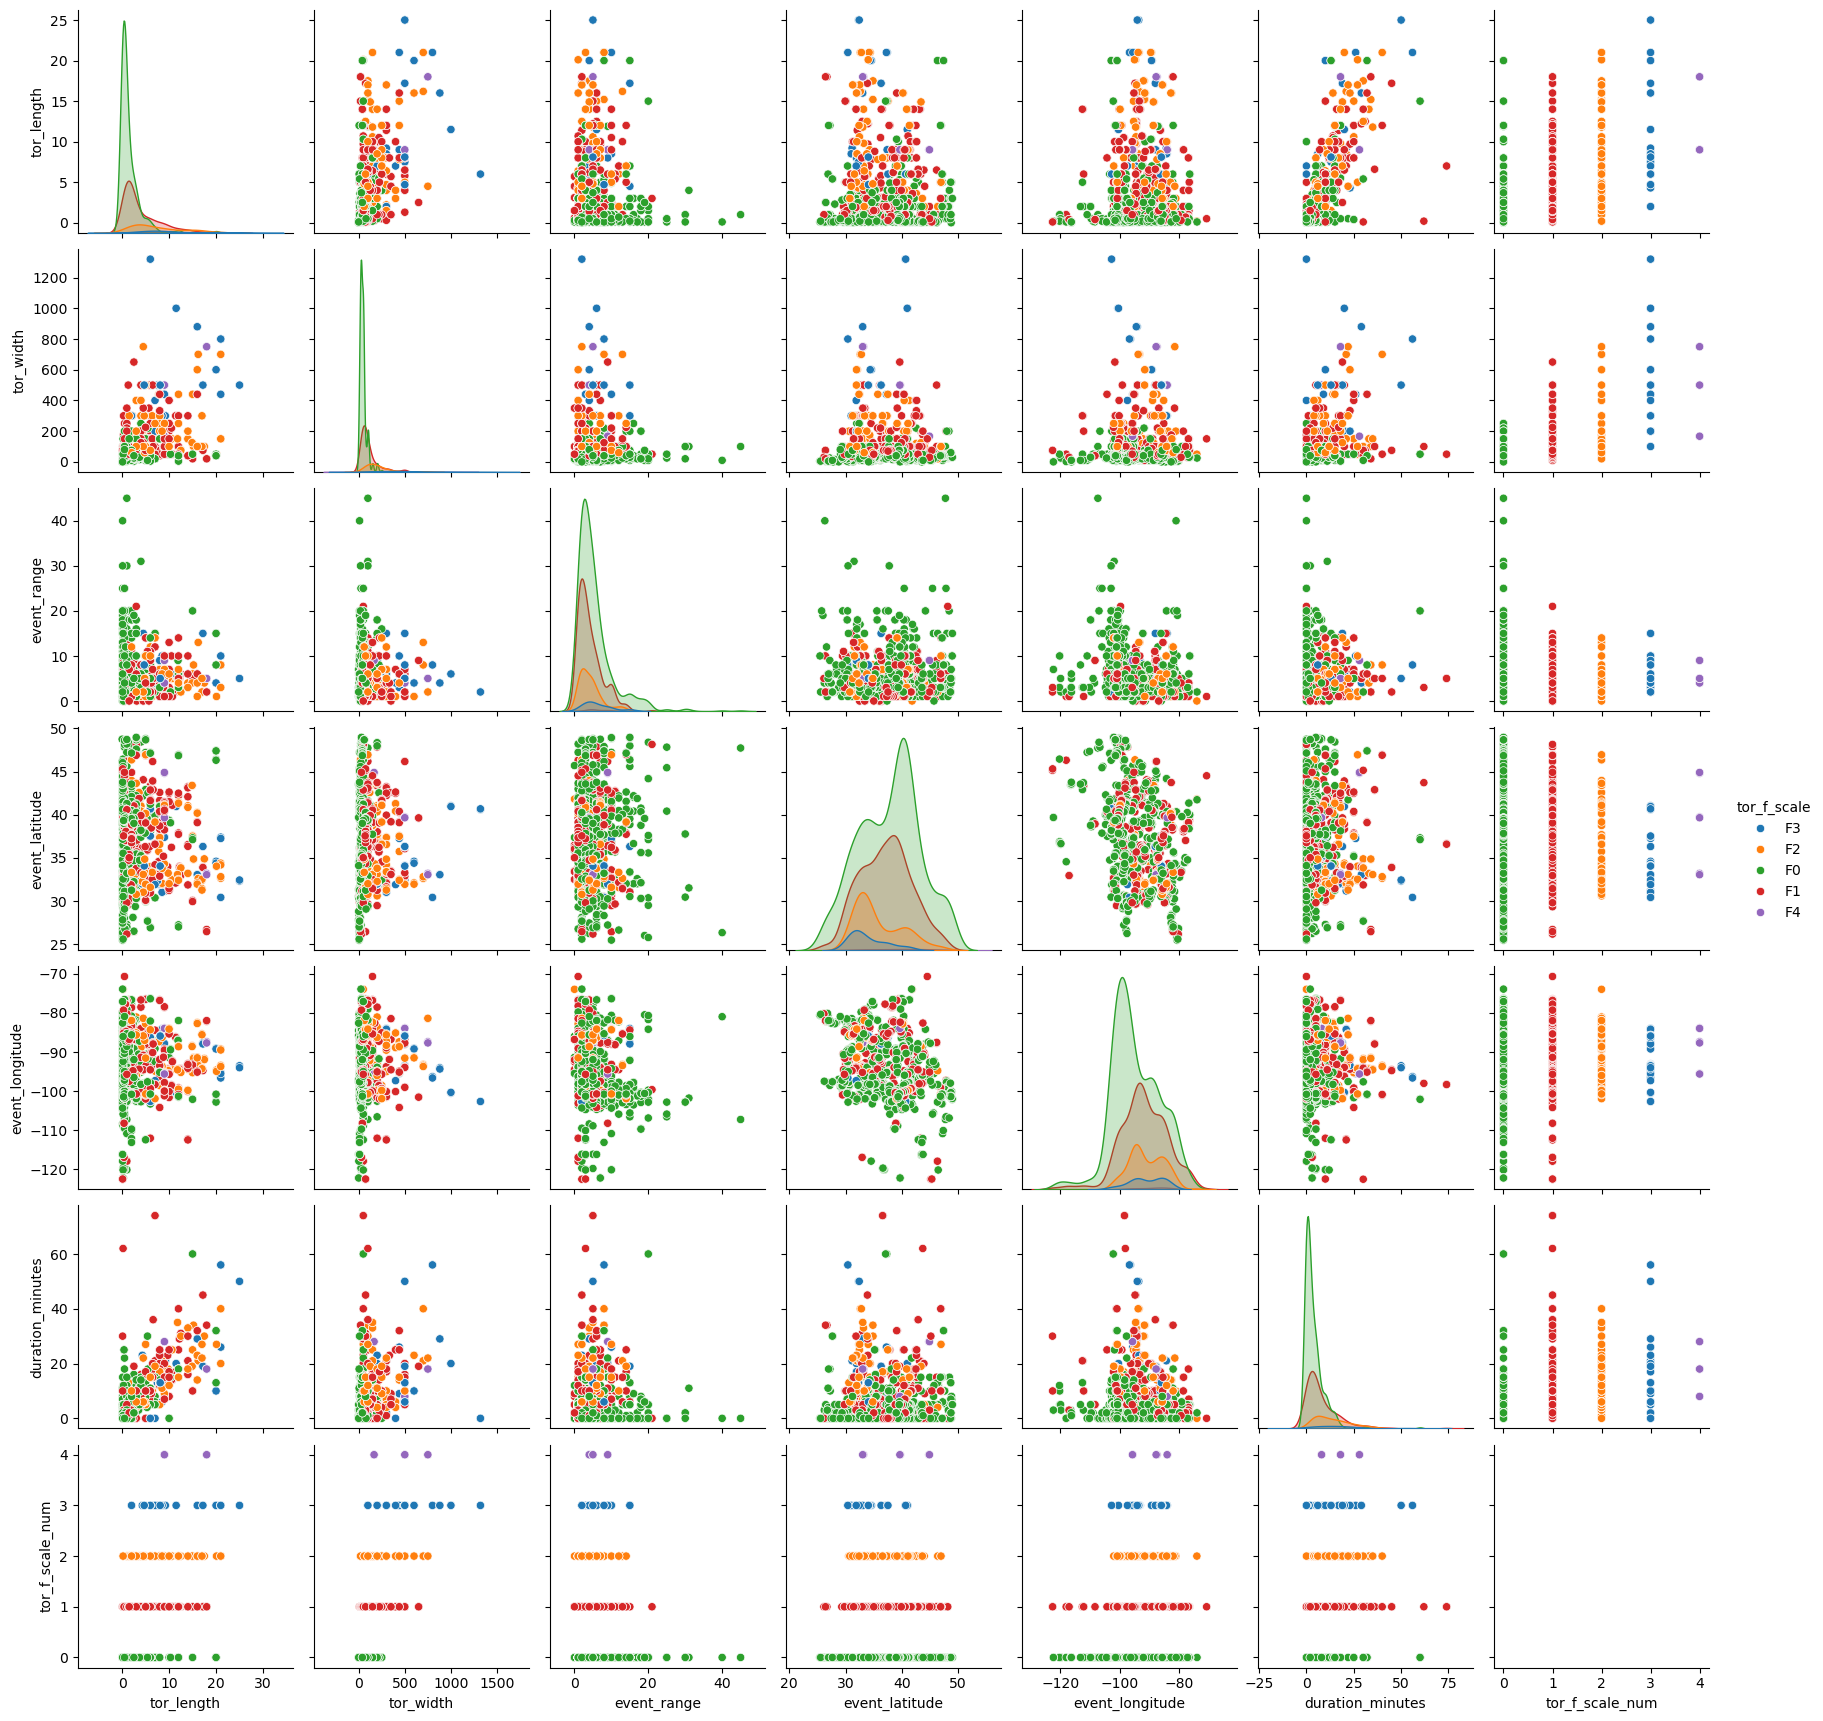

In [14]:
sns.pairplot(df_clean, hue ='tor_f_scale') #make pair plot use the scale for hue to be able to seperate the scales visually 

In [15]:
# select only numeric columns
numeric_cols = df_clean.select_dtypes(include=['number']).columns


# compute correlation
corr = df_clean[numeric_cols].corr()
print(corr)


                  tor_length  tor_width  event_range  event_latitude  \
tor_length          1.000000   0.510445     0.076488       -0.080040   
tor_width           0.510445   1.000000     0.014761       -0.079269   
event_range         0.076488   0.014761     1.000000        0.004145   
event_latitude     -0.080040  -0.079269     0.004145        1.000000   
event_longitude     0.013303   0.038248    -0.239443       -0.343858   
duration_minutes    0.778365   0.394032     0.084372       -0.050834   
tor_f_scale_num     0.560019   0.637956    -0.065554       -0.149753   

                  event_longitude  duration_minutes  tor_f_scale_num  
tor_length               0.013303          0.778365         0.560019  
tor_width                0.038248          0.394032         0.637956  
event_range             -0.239443          0.084372        -0.065554  
event_latitude          -0.343858         -0.050834        -0.149753  
event_longitude          1.000000         -0.075966         0.187664

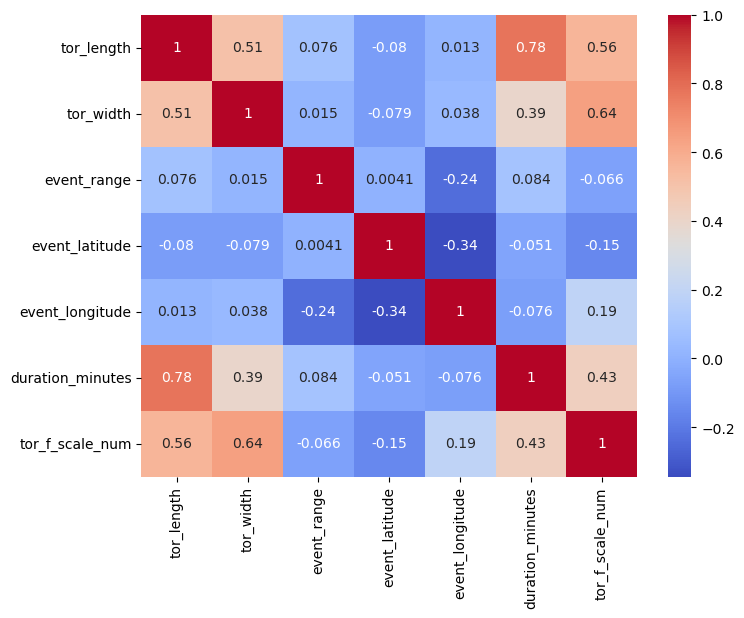

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Some notes based on the findings of the correlation
duration seems to have a positive correlation with event range and tornado length 
the range seems to be self explanatory with the longer it goes on allowing it to travel father within its lifetime

Meanwhile the scale of the tornado seems to correlate softly with both the length and width of the tornado 

In [17]:
#Turning data to csv for tableu

df_clean.to_csv('my_data.csv', index=False)

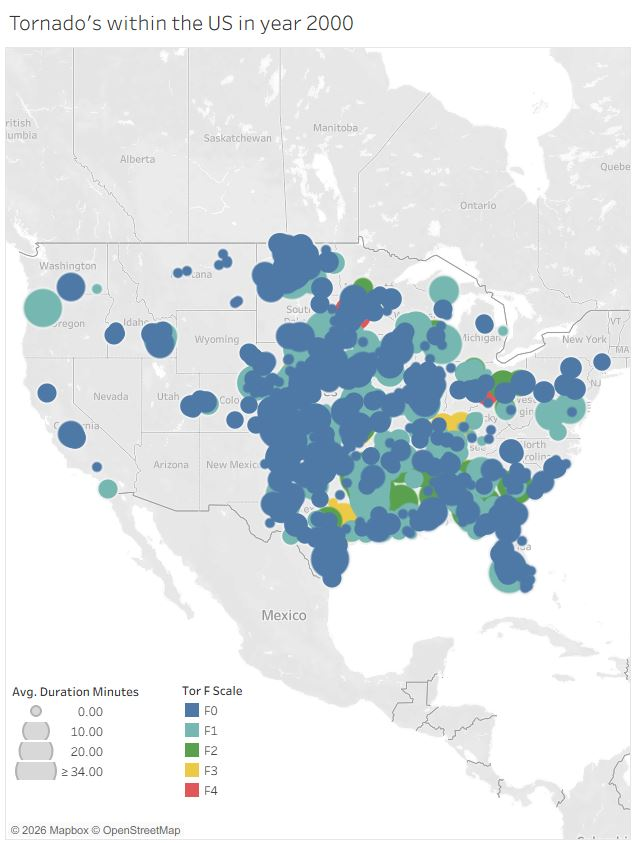

In [18]:
display(Image(filename="Tableu Tornado.jpg", width=400))

Question: Are the following durations of this year of US tornados significantly different from the average? Assuming the average is 5 minutes stated by the same organization the data is from 

* <b>Null hypothesis</b>: duration of tornados come from a population of average rating = 5 ($\mu = 5$)
* <b>Alternative hypothesis</b>: duration of tornados do not come from a population of average rating 5 ($\mu > 5$)
* <b>Significance level</b>: assume it to be 5%

In [19]:
data = df_clean['duration_minutes']

In [20]:
t_stat, p_value = stats.ttest_1samp(data, 5, alternative='greater')


In [21]:
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 6.628178478172605
p-value: 2.4541372733726203e-11


Sample mean is 6 standard deviations away from a mean of 5 
 P value is tiny and under alpha of 0.05 so reject null hypothesis 

In [22]:
df_clean.describe()

,tor_length,tor_width,event_range,event_latitude,event_longitude,duration_minutes,tor_f_scale_num
count,1344.00000,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000
mean,3.16131,98.122396,4.915923,37.297173,-93.380965,6.583333,0.612351
std,4.27239,135.402535,4.437998,5.066582,7.882087,8.757453,0.823625
min,0.00000,0.000000,0.000000,25.466670,-122.616670,0.000000,0.000000
25%,0.30000,25.000000,2.000000,33.183330,-98.929170,1.000000,0.000000
50%,1.50000,50.000000,4.000000,37.525000,-94.083335,4.000000,0.000000
75%,4.00000,100.000000,6.000000,40.716670,-87.416670,10.000000,1.000000
max,25.00000,1320.000000,45.000000,48.966670,-70.683330,74.000000,4.000000


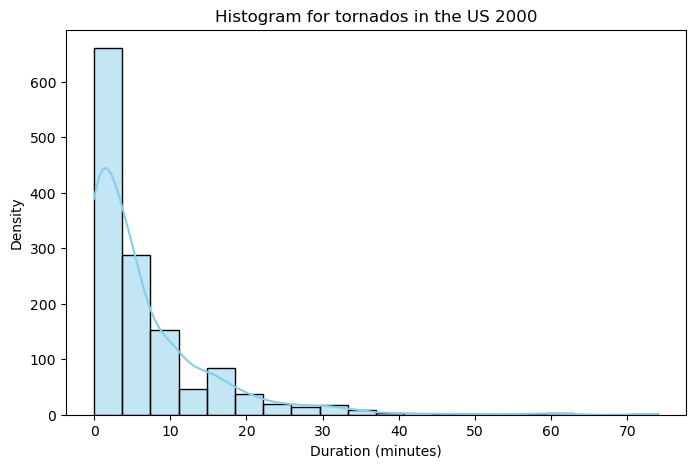

In [41]:


# Example: skewed data
data = df_clean['duration_minutes']

plt.figure(figsize=(8,5))
sns.histplot(data, bins=20, kde=True, color='skyblue')
plt.title('Histogram for tornados in the US 2000')
plt.xlabel('Duration (minutes)')
plt.ylabel('Density')
plt.show()

Why could this be so I looked a little about what happened in the year 2000 for tornadoes in the US and found that while it didn't seem to be that notable in terms of tornadoes it did have a few large ones that could be drastically effecting the mean due to the range of how long tornadoes can last